## Part A — Data preparation

##### Load Data

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
# Load datasets
fear = pd.read_csv("C:/Users/tkhar/Desktop/Assignment_1/DataAnalytics - tutedude/python/internship/fear_greed_index.csv")
trades = pd.read_csv("C:/Users/tkhar/Desktop/Assignment_1/DataAnalytics - tutedude/python/internship/historical_data.csv")

In [61]:
# Preview
print(fear.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

##### Basic Understanding of both dataset

In [7]:
# Shape
print("Fear shape:", fear.shape)
print("Trades shape:", trades.shape)

Fear shape: (2644, 4)
Trades shape: (211224, 16)


#### fear_greed_index.csv contains 4 columns and 2644 rows
#### historical_data.csv contains 16 columns and 211224 rows

In [37]:
# Columns
print(fear.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [38]:
# Info
fear.info()
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-nu

#### Missing Values

In [10]:
print(fear.isnull().sum())
print(trades.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


#### Checking Duplicates in both datasets

In [39]:
print("Fear duplicates:", fear.duplicated().sum())
print("Trades duplicates:", trades.duplicated().sum())

Fear duplicates: 0
Trades duplicates: 0


#### Fixing Dates and aligning the datasets by date

In [100]:
fear['date'] = pd.to_datetime(fear['date'],format='mixed', dayfirst=True,  errors='coerce')


In [101]:
trades['date'] = pd.to_datetime(trades['Timestamp IST'],  dayfirst=True)
trades['date'] = trades['date'].dt.date
fear['date'] = fear['date'].dt.date

In [102]:
fear.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [103]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [104]:
fear.dtypes

timestamp          int64
value              int64
classification    object
date              object
dtype: object

In [105]:
trades.dtypes

Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
date                 object
dtype: object

#### Merging both the datasets

In [106]:
merged = pd.merge(trades, fear, on='date', how='left')
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [107]:
merged.dtypes

Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
date                 object
timestamp           float64
value               float64
classification       object
dtype: object

### Metrics Creation

##### Daily PnL
##### Win Rate
##### Avg Trade Size
##### Trades per day
##### Long vs Short ratio


In [108]:
merged.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'timestamp', 'value', 'classification'],
      dtype='object')

##### Daily PnL

In [109]:
daily_pnl = merged.groupby('date')['Closed PnL'].sum().reset_index()
daily_pnl.rename(columns={'Closed PnL': 'daily_pnl'}, inplace=True)
daily_pnl.head()

,date,daily_pnl
0,2023-05-01,0.000000
1,2023-12-05,0.000000
2,2023-12-14,-205.434737
3,2023-12-15,-24.632034
4,2023-12-16,0.000000


##### Win Rate

In [110]:
merged['win'] = merged['Closed PnL'] > 0
win_rate = merged.groupby('date')['win'].mean().reset_index()
win_rate.rename(columns={'win': 'win_rate'}, inplace=True)
win_rate.head()

,date,win_rate
0,2023-05-01,0.000000
1,2023-12-05,0.000000
2,2023-12-14,0.363636
3,2023-12-15,0.000000
4,2023-12-16,0.000000


##### Average Trade Size

In [111]:
avg_size = merged.groupby('date')['Size USD'].mean().reset_index()
avg_size.rename(columns={'Size USD': 'avg_trade_size'}, inplace=True)
avg_size.head()

,date,avg_trade_size
0,2023-05-01,159.000000
1,2023-12-05,5556.203333
2,2023-12-14,10291.213636
3,2023-12-15,5304.975000
4,2023-12-16,5116.256667


##### Trades per Day

In [112]:
trades_per_day = merged.groupby('date').size().reset_index(name='num_trades')
trades_per_day.head()

,date,num_trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


##### Long vs Short Ratio

In [113]:
long_short = merged.groupby(['date', 'Side']).size().unstack(fill_value=0)
# Create ratio
long_short['long_short_ratio'] = long_short['BUY'] / (long_short['SELL'] + 1)
long_short = long_short.reset_index()
long_short.head()

Side,date,BUY,SELL,long_short_ratio
0,2023-05-01,3,0,3.000000
1,2023-12-05,7,2,2.333333
2,2023-12-14,5,6,0.714286
3,2023-12-15,2,0,2.000000
4,2023-12-16,3,0,3.000000


In [114]:
merged.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'timestamp', 'value', 'classification', 'win'],
      dtype='object')

##### Combining All Metrics

In [115]:
final_df = daily_pnl.merge(win_rate, on='date') \
                    .merge(avg_size, on='date') \
                    .merge(trades_per_day, on='date') \
                    .merge(long_short[['date', 'long_short_ratio']], on='date')

In [116]:
# final_df = final_df.merge(fear[['date', 'classification']], on='date', how='left')

final_df['date'] = pd.to_datetime(final_df['date']).dt.date
fear['date'] = pd.to_datetime(fear['date']).dt.date

final_df = final_df.merge(
    fear[['date', 'classification']],
    on='date',
    how='left'
)

In [117]:
final_df.head()

,date,daily_pnl,win_rate,avg_trade_size,num_trades,long_short_ratio,classification
0,2023-05-01,0.000000,0.000000,159.000000,3,3.000000,Greed
1,2023-12-05,0.000000,0.000000,5556.203333,9,2.333333,Extreme Greed
2,2023-12-14,-205.434737,0.363636,10291.213636,11,0.714286,Greed
3,2023-12-15,-24.632034,0.000000,5304.975000,2,2.000000,Greed
4,2023-12-16,0.000000,0.000000,5116.256667,3,3.000000,Greed


## PART B (Analysis)

#### Fear vs Greed Analysis

In [123]:
# Basic undertanding of data
final_df['classification'].value_counts()

classification
Greed            193
Extreme Greed    114
Fear              91
Neutral           67
Extreme Fear      14
Name: count, dtype: int64

In [124]:
final_df.shape

(480, 7)

In [118]:
#Group by Sentiment
sentiment_analysis = final_df.groupby('classification').agg({
    'daily_pnl': 'mean',
    'win_rate': 'mean',
    'avg_trade_size': 'mean',
    'num_trades': 'mean',
    'long_short_ratio': 'mean'
}).reset_index()



In [119]:
sentiment_analysis

,classification,daily_pnl,win_rate,avg_trade_size,num_trades,long_short_ratio
0,Extreme Fear,52793.589178,0.327341,4091.804366,1528.571429,1.141476
1,Extreme Greed,23817.292199,0.467424,4410.524482,350.807018,1.686797
2,Fear,36891.818040,0.329112,6524.294937,679.527473,3.229182
3,Greed,11140.566181,0.335986,6735.295813,260.637306,2.720932
4,Neutral,19297.323516,0.331886,7157.527121,562.477612,2.533303


### PnL Comparison

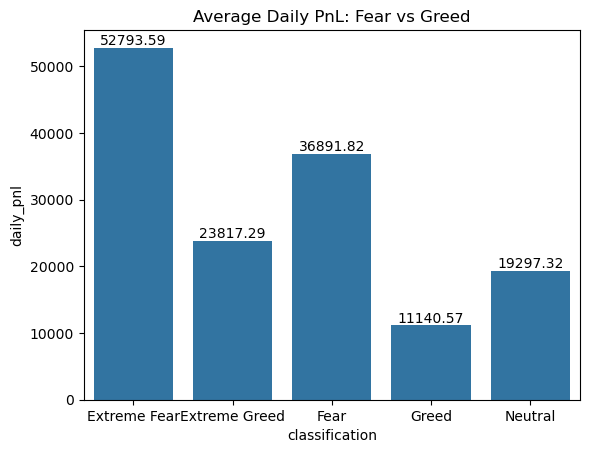

In [135]:
ax = sns.barplot(x='classification', y='daily_pnl', data=sentiment_analysis)
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",   
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.title("Average Daily PnL: Fear vs Greed")
plt.show()

### Win Rate Comparison

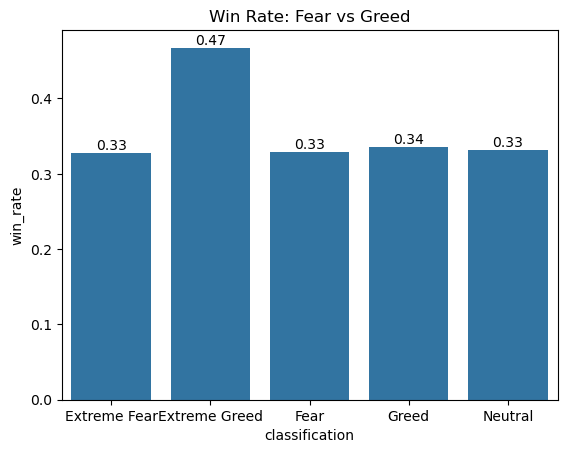

In [136]:
ax = sns.barplot(x='classification', y='win_rate', data=sentiment_analysis)
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",   
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.title("Win Rate: Fear vs Greed")
plt.show()

### Trade Behavior

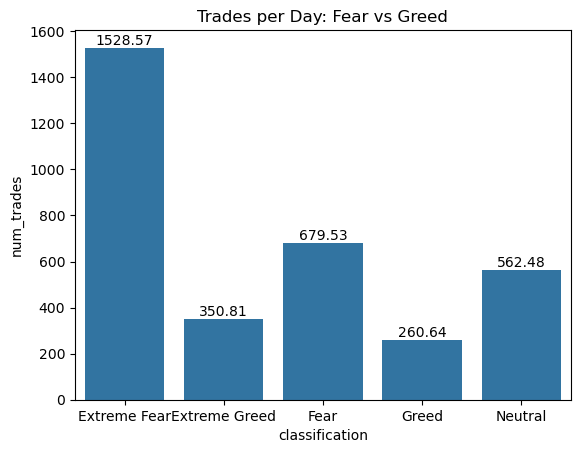

In [137]:
ax = sns.barplot(x='classification', y='num_trades', data=sentiment_analysis)
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",  
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.title("Trades per Day: Fear vs Greed")
plt.show()

## Behavior Change Analysis

### Trade Size

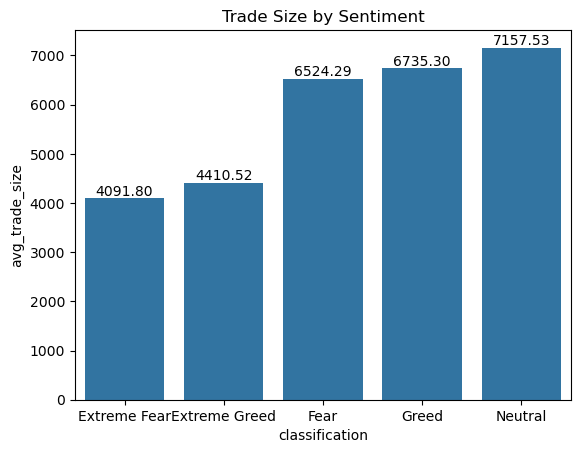

In [138]:
ax = sns.barplot(x='classification', y='avg_trade_size', data=sentiment_analysis)
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",   
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.title("Trade Size by Sentiment")
plt.show()

### Long/Short Bias

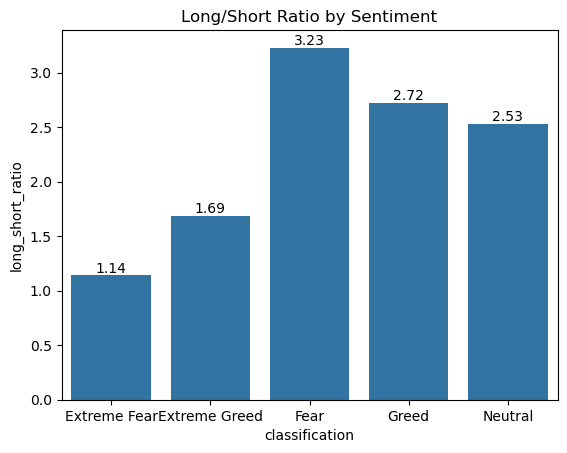

In [139]:
ax = sns.barplot(x='classification', y='long_short_ratio', data=sentiment_analysis)
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",   
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.title("Long/Short Ratio by Sentiment")
plt.show()

## Segmentation

#### High vs Low Activity

In [130]:
activity = merged.groupby('Account').size().reset_index(name='trade_count')
activity['segment'] = activity['trade_count'].apply(
    lambda x: 'High Activity' if x > activity['trade_count'].median() else 'Low Activity'
)
activity.head()

,Account,trade_count,segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,High Activity
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,High Activity
2,0x271b280974205ca63b716753467d5a371de622ab,3809,High Activity
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,High Activity
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Low Activity


In [131]:
activity.shape

(32, 3)

In [132]:
merged = merged.merge(activity[['Account', 'segment']], on='Account')

In [133]:
segment_analysis = merged.groupby(['segment', 'classification'])['Closed PnL'].mean().reset_index()
segment_analysis

,segment,classification,Closed PnL
0,High Activity,Extreme Fear,34.163353
1,High Activity,Extreme Greed,62.870911
2,High Activity,Fear,51.323784
3,High Activity,Greed,25.004641
4,High Activity,Neutral,34.579701
5,Low Activity,Extreme Fear,35.941979
6,Low Activity,Extreme Greed,103.264685
7,Low Activity,Fear,80.835791
8,Low Activity,Greed,210.210287
9,Low Activity,Neutral,31.845656


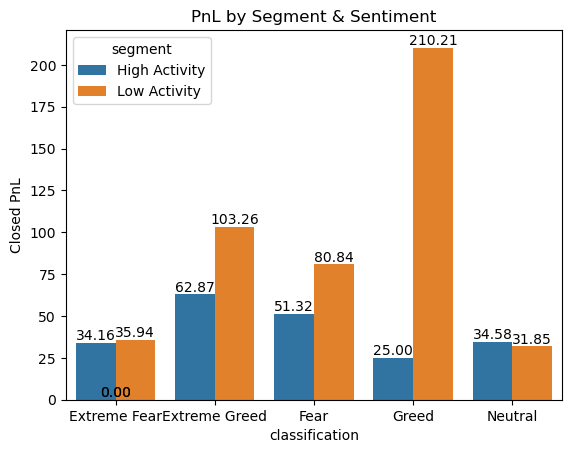

In [140]:
ax = sns.barplot(x='classification', y='Closed PnL', hue='segment', data=segment_analysis)
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",   
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.title("PnL by Segment & Sentiment")
plt.show()

## Observations
##### 1) PnL highest in Extreme Fear (52793)
##### -> Opportunity during panic
##### 2) Win rate highest in Extreme Greed (0.47)
##### -> Trend-following works better
##### 3) Trades highest in Extreme Fear (1528)
##### -> Overtrading / panic trading
##### 4) Trade size highest in Neutral/Greed
##### -> Confidence high in stable markets
##### 5) Long bias strong in Fear (3.39)
##### -> Traders aggressively buy dips
##### 6)Low activity traders outperform in Greed
##### -> Overtrading hurts performance

## Strategies


### 1) Contrarian Strategy during Fear
##### During Fear and Extreme Fear periods, increase participation but control trade size and avoid overtrading.
#### Logic:
##### PnL highest in Extreme Fear
##### Traders panic → mispricing opportunities
##### Win rate low (~0.33)
##### Trade count very high (overtrading risk)
#### Actionable Steps:
##### Enter market during Fear phases
##### Use smaller position sizes
##### Avoid excessive trades (limit trades/day)
##### Focus on high-conviction trades only
#### Conclusion:
##### Fear-driven markets offer high PnL opportunities, but require disciplined execution due to low win rates and high noise.

### 2) Selective Trading in Greed (Low Activity Advantage)
##### During Greed and Extreme Greed, reduce trade frequency and focus on fewer, high-quality trades.
#### Logic:
##### Win rate highest in Extreme Greed (0.47)
##### Low activity traders perform best:
##### Greed → 210 PnL (low activity) vs 25 (high activity)
##### Overtrading reduces profitability
#### Actionable Steps:
##### Trade less, but smarter
##### Increase position size slightly (confidence high)
##### Follow trend (momentum works)
##### Avoid frequent entries/exits
#### Conclusion:
##### In bullish sentiment, disciplined low-frequency trading outperforms aggressive trading.


### 3) Avoid Overtrading in High Volatility
##### High trade frequency negatively impacts performance, especially in Fear conditions.
#### Logic:
##### Extreme Fear → 1500+ trades/day
##### But win rate low (0.33)
#### Conclusion:
##### More trades does not generate more profit